## **CSE330 Section 03 Special Assignment Summer 2024** (Total Marks : 10)

In [53]:
Name = "Sadman Rahman"
ID = "22101008"
Section = "03"

In [54]:
import pandas as pd
import numpy as np
from numpy.polynomial import Polynomial
import matplotlib.pyplot as plt

# Question 01 [1 + 2 + 1.5 + 1.5 Marks]

Consider the following function:
$$ f(x) = x^3 - 6x^2 + 11x -6 $$



1(i) Print and plot the Actual roots, `x*`, of the given function. Round the roots to 4 decimal places.

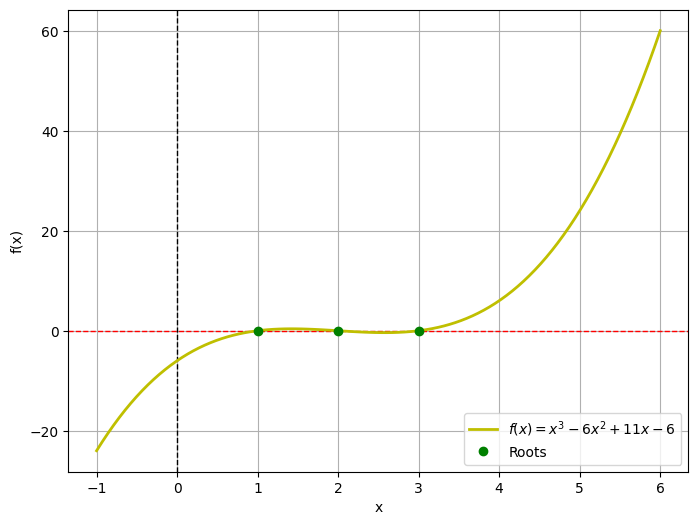

Actual roots (rounded to 4 decimal places): [1. 2. 3.]
   Roots
0    1.0
1    2.0
2    3.0


In [55]:
f = Polynomial([-6.0, 11.0, -6.0, 1.0])
x = np.linspace(-1, 6, 100)
y = f(x)
dictionary = {
    'x': x,
    'y': y
}
plt.figure(figsize=(8, 6))
plt.axhline(y=0, color='r', linestyle='--', linewidth=1)
plt.axvline(x=0, color='k', linestyle='--', linewidth=1)
plt.plot(x, y, 'y', label=r'$f(x) = x^3 - 6x^2 + 11x - 6$', linewidth=2)
roots = f.roots()
plt.plot(roots, [0.0]*len(roots), 'go', label='Roots')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()
rounded_roots = np.round(roots, 4)
print(f"Actual roots (rounded to 4 decimal places): {rounded_roots}")
df = pd.DataFrame(rounded_roots, columns=["Roots"])
print(df)

**1(ii)** The following $g_{1}(x)$ is given which is derived from the above $f(x)$\
$$g_{1}(x) = \frac{-x^3 +6x^2 + 6}{11}$$\
Use Contraction Mapping Theorem and calculate the value of λ for all the actual roots. Print whether the $g_{1}(x)$ is converging or diverging.





In [56]:
def g1(x):
    return (-x**3 + 6*x**2 + 6)/11
def g1_p(x):
    return (-3*x**2 + 12*x)/11
roots = np.array([1.0, 2.0, 3.0])
g1_p_val = g1_p(roots)
con = np.abs(g1_p_val) < 1
df = pd.DataFrame({
    'Root': roots,
    "g1'(x)": g1_p_val,
    'Converging': con
})
print(df)
for i, root in enumerate(roots):
    if con[i]:
        print(f"At root x = {root}, |g1'(x)| = {abs(g1_p_val[i]):.4f} < 1, so g1(x) is converging.")
    else:
        print(f"At root x = {root}, |g1'(x)| = {abs(g1_p_val[i]):.4f} >= 1, so g1(x) is diverging.")

   Root    g1'(x)  Converging
0   1.0  0.818182        True
1   2.0  1.090909       False
2   3.0  0.818182        True
At root x = 1.0, |g1'(x)| = 0.8182 < 1, so g1(x) is converging.
At root x = 2.0, |g1'(x)| = 1.0909 >= 1, so g1(x) is diverging.
At root x = 3.0, |g1'(x)| = 0.8182 < 1, so g1(x) is converging.


**1(iii)** Derive 3 more separate $g_{2}(x)$, $g_{3}(x)$ and $g_{4}(x)$ from the given $f(x)$. Represent those in the code.

In [57]:
def f(x):
    return x**3 - 6*x**2 + 11*x - 6
def g2(x):
    return 6/(x**2 - 6*x + 11)
def g3(x):
    return np.sqrt((x**3 + 11*x - 6) / 6)
def g4(x):
    return np.cbrt(6*x**2 - 11*x + 6)
roots = np.array([1.0, 2.0, 3.0])
def g2_p(x):
    return (-6*(2*x-6))/((x**2 - 6*x + 11)**2)
def g3_p(x):
    return (3*x**2 + 11)/(12*((x**3 + 11*x - 6)/6)**.5)
def g4_p(x):
    return (12*x - 11) / (3 * (6*x**2-11*x+6)**(.67))
g2_p_val = g2_p(roots)
g3_p_val = g3_p(roots)
g4_p_val = g4_p(roots)
con_g2 = np.abs(g2_p_val) < 1
con_g3 = np.abs(g3_p_val) < 1
con_g4 = np.abs(g4_p_val) < 1
df = pd.DataFrame({
    'Root': roots,
    "g2'(x)": g2_p_val,
    'g2 Converging': con_g2,
    "g3'(x)": g3_p_val,
    'g3 Converging': con_g3,
    "g4'(x)": g4_p_val,
    'g4 Converging': con_g4
})
print(df)
for i, root in enumerate(roots):
    print(f"At root x = {root}:")
    if con_g2[i]:
        print(f"  g2(x) is converging with |g2'(x)| = {abs(g2_p_val[i]):.4f}")
    else:
        print(f"  g2(x) is diverging with |g2'(x)| = {abs(g2_p_val[i]):.4f}")
    if con_g3[i]:
        print(f"  g3(x) is converging with |g3'(x)| = {abs(g3_p_val[i]):.4f}")
    else:
        print(f"  g3(x) is diverging with |g3'(x)| = {abs(g3_p_val[i]):.4f}")
    if con_g4[i]:
        print(f"  g4(x) is converging with |g4'(x)| = {abs(g4_p_val[i]):.4f}")
    else:
        print(f"  g4(x) is diverging with |g4'(x)| = {abs(g4_p_val[i]):.4f}")

   Root    g2'(x)  g2 Converging    g3'(x)  g3 Converging    g4'(x)  \
0   1.0  0.666667           True  1.166667          False  0.333333   
1   2.0  1.333333          False  0.958333           True  1.075850   
2   3.0 -0.000000           True  1.055556          False  0.915809   

   g4 Converging  
0           True  
1          False  
2           True  
At root x = 1.0:
  g2(x) is converging with |g2'(x)| = 0.6667
  g3(x) is diverging with |g3'(x)| = 1.1667
  g4(x) is converging with |g4'(x)| = 0.3333
At root x = 2.0:
  g2(x) is diverging with |g2'(x)| = 1.3333
  g3(x) is converging with |g3'(x)| = 0.9583
  g4(x) is diverging with |g4'(x)| = 1.0759
At root x = 3.0:
  g2(x) is converging with |g2'(x)| = 0.0000
  g3(x) is diverging with |g3'(x)| = 1.0556
  g4(x) is converging with |g4'(x)| = 0.9158


**1(iv)** Find the approximate root, `x*`, of the above function using Fixed Point Iterations where $x_{0}$ = 1.1 and any of the converging `g(x)` that you have constructed in 1(iii). Show 20 iterations.

In [58]:
def g4(x):
    return (6*x**2 - 11*x + 6)**(1/3)
x0 = 1.1
times = 20
res = []
x = x0
for i in range(times):
    x1 = g4(x)
    res.append((i, x, x1))
    x = x1
print(f"{'Iteration':<10} {'x_n':<20} {'x_(n+1)':<20}")
for i, x_n, x_np1 in res:
    print(f"{i:<10} {x_n:<20} {x_np1:<20}")
print(f' Approximate root: x*= {x_np1}')

Iteration  x_n                  x_(n+1)             
0          1.1                  1.0507175744985804  
1          1.0507175744985804   1.0215812998731948  
2          1.0215812998731948   1.00806013137104    
3          1.00806013137104     1.0028087454553054  
4          1.0028087454553054   1.0009511216679343  
5          1.0009511216679343   1.0003187482096163  
6          1.0003187482096163   1.0001064412739011  
7          1.0001064412739011   1.0000355018237288  
8          1.0000355018237288   1.0000118363219028  
9          1.0000118363219028   1.0000039457052627  
10         1.0000039457052627   1.0000013152644949  
11         1.0000013152644949   1.0000004384247663  
12         1.0000004384247663   1.000000146141952   
13         1.000000146141952    1.0000000487140246  
14         1.0000000487140246   1.0000000162380127  
15         1.0000000162380127   1.0000000054126712  
16         1.0000000054126712   1.0000000018042237  
17         1.0000000018042237   1.000000000601

#Question 02 [4 Marks]

Consider the following function:
$$ f(x) = 5x^6-x^5+7x^4+3.75x^3-2x^2+1.5x+15 $$
Now, compute the Second Degree Richarson Extrapolation, `D^{2}` at `x = 1` and `h = 0.3` when the formula is derived using `h -> h/4`. Print the answer upto 2 decimal places.

**N.B.** You can use the previously learned methods while solving the problem.

In [59]:
def f(x):
    return 5*x**6 - x**5 + 7*x**4 + 3.75*x**3 - 2*x**2 + 1.5*x + 15
def central_difference(f, x, h):
    return (f(x + h) - f(x - h)) / (2 * h)
def first_degree_richardson(f, x, h):
    D_h = central_difference(f, x, h)
    D_h4 = central_difference(f, x, h / 4)
    D1_h = (16 * D_h4 - D_h) / 15
    return D1_h
def second_degree_richardson(f, x, h):
    D1_h = first_degree_richardson(f, x, h)
    D1_h4 = first_degree_richardson(f, x, h / 4)
    D2_h = (256 * D1_h4 - D1_h) / 255
    return D2_h
x1 = 1
h = 0.3
derivative_approx = second_degree_richardson(f, x1, h)
print(f"The Second Degree Richarson Extrapolation of f'(x) at x = {x1} is: {derivative_approx:.2f}")

The Second Degree Richarson Extrapolation of f'(x) at x = 1 is: 61.75
